# SPEAR-HI25 (2025-2059) 
# Map vars (Frequency, Intensity, Duration)
(>=5 consecutive days w/ a gap of >=3 days in between events for each grid cell)

|  | OISST | ERA5 | SPEAR-LO | SPEAR-HI |
| :---------- | :---------- | :----------: | ----------: | ----------: |
| Temperature | SST | SST | SST | SST |
| Sampling<br>frequency | Daily | Daily | Daily | Daily |
| Lat/Lon<br>resolution | 0.25˚ x 0.25˚ | 0.25˚ x 0.25˚ | 1˚ x 1˚ | 0.25˚ x 0.25˚ |
|Time period | 1981-09 : 2025-09 | 1983-01 : 2021-06 | 1981-09 : 2010-12 | 1991-01 : 2100-01 |

In [1]:
import xarray as xr
import pandas as pd
import json
import numpy as np
import cmocean
import cartopy.crs as ccrs #cartopy coord ref sys
import cartopy
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import ListedColormap
import time
from tqdm import tqdm
import glob
import os
from collections import defaultdict
import xesmf as xe
import ast #for parsing through events_by_cell.json file
import re

## Open all ensemble members for `Freq`, `Dur` and `Int` in the 3 epochs

In [23]:
base_path = '/work5/stb/MHW-gfdl/SPEAR/vars/SPEAR-HI25/period_1991-2024/map_vars/'
files = sorted(glob.glob(f'{base_path}/mean_mhw_intensity_sphi*.nc'))
[xr.open_dataset(f)["mean_intensity"].dims for f in files]

KeyError: "No variable named 'mean_intensity'. Did you mean one of ('mean_intensity_ens01',)?"

In [ ]:
import glob
import re
import xarray as xr

def open_datasets(da_name, period):

    base_path = f'/work5/stb/MHW-gfdl/SPEAR/vars/SPEAR-HI25/period_{period}/map_vars/'
    files = sorted(glob.glob(f'{base_path}/{da_name}*.nc'))

    if period != '1991-2024':
        ens_ids = [int(f.split('_')[-1].split('.nc')[0]) for f in files]
    else:
        ens_ids = [int(re.search(r'(\d+)\.nc$', f).group(1)) for f in files]

    dsets = []

    for f, ens in zip(files, ens_ids):

        ds = xr.open_dataset(f)

        # ✔️ FIX: just take the real data variable
        data_vars = list(ds.data_vars)

        if len(data_vars) == 0:
            raise ValueError(f"No data variables found in {f}")

        var = data_vars[0]   # safest assumption for your case

        da = ds[var]

        da = da.expand_dims(ensemble=[ens])
        dsets.append(da)

    return xr.concat(dsets, dim="ensemble")

In [28]:
def open_datasets(da_name, period):
    base_path = f'/work5/stb/MHW-gfdl/SPEAR/vars/SPEAR-HI25/period_{period}/map_vars/'
    files = sorted(glob.glob(f'{base_path}/{da_name}*.nc'))
    
    if period != '1991-2024':
        ens_ids = [int(f.split('_')[-1].split('.nc')[0]) for f in files]
    else:
        ens_ids = [int(re.search(r'(\d+)\.nc$', f).group(1)) for f in files]

    dsets = []
    for f, ens in zip(files, ens_ids):
        ds = xr.open_dataset(f)
        
        data_vars = list(ds.data_vars)
        if len(data_vars) == 0:
            raise ValueError(f"No data variables found in {f}")
            
        var = data_vars[0]
        da = ds[var]
        da = da.expand_dims(ensemble=[ens])

        dsets.append(da)
    
    ds_out = xr.concat(dsets, dim='ensemble', join='outer')
    
    #ds = xr.open_mfdataset(files, combine='nested', concat_dim=xr.DataArray(ens_ids, dims='ensemble', name='ensemble'),
     #                     join='outer')

    return ds_out

In [31]:
#1991-2024
median_duration91 = xr.open_dataset('/work/stb/MHW-gfdl/SPEAR/vars/SPEAR-HI25/period_1991-2024/map_vars/median_duration.nc', chunks={})
mean_mhw_intensity91 = open_datasets('mean_mhw_intensity_sphi', '1991-2024').drop_vars('quantile')
event_count91 = open_datasets('event_counts_sphi', '1991-2024')
freq91 = event_count91 / 34

#2025-2059
median_duration25 = open_datasets('median_duration', '2025-2059')
mean_mhw_intensity25 = open_datasets('mean_mhw_intensity', '2025-2059')
event_count25 = open_datasets('event_count', '2025-2059')
freq25 = event_count25.event_count / 34
#duration25 = open_datasets('duration', '2025-2059')
#duration_std_list25 = [duration25.isel(ensemble=i).duration.std('event') for i in np.arange(0,30)]
#duration_std25 = xr.concat(duration_std_list25, dim=('ensemble'))

#2060-2094
median_duration60 = open_datasets('median_duration', '2060-2094')
mean_mhw_intensity60 = open_datasets('mean_mhw_intensity', '2060-2094')
event_count60 = open_datasets('event_count', '2060-2094')
freq60 = event_count60.event_count / 34

ValueError: Dimension ensemble already exists.

In [20]:
mean_mhw_intensity91

<xarray.Dataset> Size: 211MB
Dimensions:               (ensemble: 30, yT: 90, xT: 325)
Coordinates:
  * ensemble              (ensemble) int64 240B 1 2 3 4 5 6 ... 26 27 28 29 30
  * yT                    (yT) float64 720B 10.2 10.44 10.69 ... 30.67 30.89
  * xT                    (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.4 -16.15
Data variables: (12/30)
    mean_intensity_ens01  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens02  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens03  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens04  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens05  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens06  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    ...                    ...
    mean_intensity_ens25  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens26  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens27  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens28  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens29  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens30  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>

In [4]:
freq60

<xarray.DataArray 'event_count' (ensemble: 30, yT: 90, xT: 325)> Size: 7MB
dask.array<truediv, shape=(30, 90, 325), dtype=float64, chunksize=(1, 90, 325), chunktype=numpy.ndarray>
Coordinates:
  * ensemble  (ensemble) int64 240B 1 2 3 4 5 6 7 8 ... 23 24 25 26 27 28 29 30
  * yT        (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
  * xT        (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15
    time      object 8B 2060-01-01 12:00:00
Attributes:
    units:          deg-C
    long_name:      sea surface temperature
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT

In [5]:
median_duration91

<xarray.Dataset> Size: 7MB
Dimensions:                        (ensemble: 30, yT: 90, xT: 325)
Coordinates:
  * ensemble                       (ensemble) int64 240B 0 1 2 3 ... 26 27 28 29
  * yT                             (yT) float64 720B 10.2 10.44 ... 30.67 30.89
  * xT                             (xT) float64 3kB -97.84 -97.58 ... -16.15
Data variables:
    __xarray_dataarray_variable__  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(30, 90, 325), meta=np.ndarray>

In [16]:
mean_mhw_intensity91

<xarray.Dataset> Size: 211MB
Dimensions:               (ensemble: 30, yT: 90, xT: 325)
Coordinates:
  * ensemble              (ensemble) int64 240B 1 2 3 4 5 6 ... 26 27 28 29 30
  * yT                    (yT) float64 720B 10.2 10.44 10.69 ... 30.67 30.89
  * xT                    (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.4 -16.15
Data variables: (12/30)
    mean_intensity_ens01  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens02  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens03  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens04  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens05  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens06  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    ...                    ...
    mean_intensity_ens25  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens26  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens27  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens28  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens29  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens30  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>

In [10]:
mean_mhw_intensity60

<xarray.Dataset> Size: 7MB
Dimensions:         (ensemble: 30, yT: 90, xT: 325)
Coordinates:
  * ensemble        (ensemble) int64 240B 1 2 3 4 5 6 7 ... 24 25 26 27 28 29 30
  * yT              (yT) float64 720B 10.2 10.44 10.69 ... 30.46 30.67 30.89
  * xT              (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.4 -16.15
    quantile        float64 8B 0.9
Data variables:
    mean_intensity  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>

## Plotting func

In [14]:
def cartopy_plot(da, cmap_choice, var_title=None, norm=None, ax=None):
    if ax is None:
        raise ValueError("This function now requires an axis when used for panels")

    ax.set_extent([-98, -60, 17.5, 31], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='0.5'))

    # ---- model agnostic: infer coord names ----
    lat_name = next(c for c in ['lat','latitude','yT','yh'] if c in da.coords)
    lon_name = next(c for c in ['lon','longitude','xT','xh'] if c in da.coords)
    
    if lat_name is None or lon_name is None:
        raise ValueError(f"Could not infer lat/lon coordinates. " f"Found coords: {list(da.coords)}")
    # --------------------------------------------
    im = ax.pcolormesh(da[lon_name], da[lat_name], da, transform=ccrs.PlateCarree(), 
                       cmap=cmap_choice, norm=norm)

    ax.set_title(var_title, fontsize=10)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3)
    gl.xlabels_top = False
    gl.ylabels_right = False

    return im # return the image for optional colorbar handling

In [15]:
def cartopy_plot_single(da, cmap_choice, cbar_label, var_title, vmin=None, vmax=None, norm=None, quiver=True):
    proj = ccrs.Mercator() #with Mercator you can put lat lon values.
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection=proj))
    ax.set_extent([-98, -60, 17.5, 31], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                            edgecolor='face',
                                            facecolor='0.5'))
    # ---- infer coord names if not provided ----
    lat_candidates = ['lat', 'latitude', 'yT', 'yh']
    lon_candidates = ['lon', 'longitude', 'xT', 'xh']

    lat_name = next((c for c in lat_candidates if c in da.coords), None)
    lon_name = next((c for c in lon_candidates if c in da.coords), None)

    if lat_name is None or lon_name is None:
        raise ValueError(
            f"Could not infer lat/lon coordinates. "
            f"Found coords: {list(da.coords)}"
        )

    lats = da[lat_name]
    lons = da[lon_name]

    # ---- normalization logic ----
    if norm is None:
        # simple linear scaling
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
    else:
        # override norm limits if vmin/vmax are supplied
        if vmin is not None:
            norm.vmin = vmin
        if vmax is not None:
            norm.vmax = vmax
    # -------------------------------------------------------------------------------
    im = ax.pcolormesh(lons, lats, da, transform=ccrs.PlateCarree(), 
                       norm=norm, cmap=cmap_choice)
    cb = fig.colorbar(im, ax=ax, shrink=0.25, pad=0.1)
    cb.set_label(fr"{cbar_label}", labelpad=8, fontsize=12)
    g1 = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    g1.xlabels_top = False
    g1.ylabels_right = False
    plt.title(f'{var_title}', fontsize=14, y=1.09)

## (2025-2059) minus (1991-2024)

In [ ]:
freq_diff_2591 = freq25 - freq91
int_diff_2591 = mean_mhw_intensity25.mean_intensity - mean_mhw_intensity91

In [7]:
mean_mhw_intensity91

<xarray.Dataset> Size: 211MB
Dimensions:               (ensemble: 30, yT: 90, xT: 325)
Coordinates:
  * ensemble              (ensemble) int64 240B 1 2 3 4 5 6 ... 26 27 28 29 30
  * yT                    (yT) float64 720B 10.2 10.44 10.69 ... 30.67 30.89
  * xT                    (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.4 -16.15
Data variables: (12/30)
    mean_intensity_ens01  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens02  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens03  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens04  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens05  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens06  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    ...                    ...
    mean_intensity_ens25  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens26  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens27  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens28  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens29  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>
    mean_intensity_ens30  (ensemble, yT, xT) float64 7MB dask.array<chunksize=(1, 90, 325), meta=np.ndarray>

## Maps

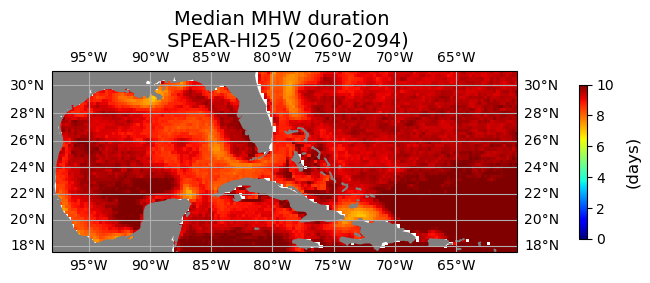

In [30]:
cartopy_plot_single(ens_mean_dur, 'jet', '(days)', 
             'Median MHW duration \n SPEAR-HI25 (2060-2094)', vmin=0, vmax=10);#if time res is daily

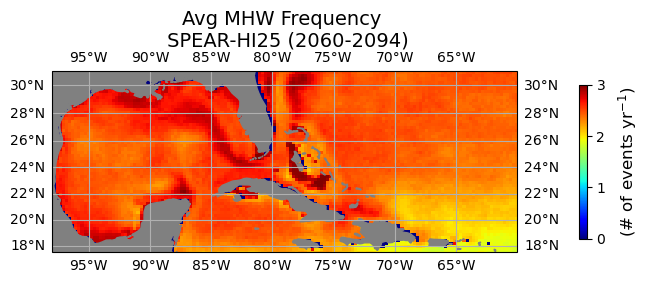

In [31]:
cartopy_plot_single(ens_mean_freq, 'jet', r'(# of events yr$^{-1}$)', 
                    'Avg MHW Frequency \n SPEAR-HI25 (2060-2094)', vmin=0, vmax=3);

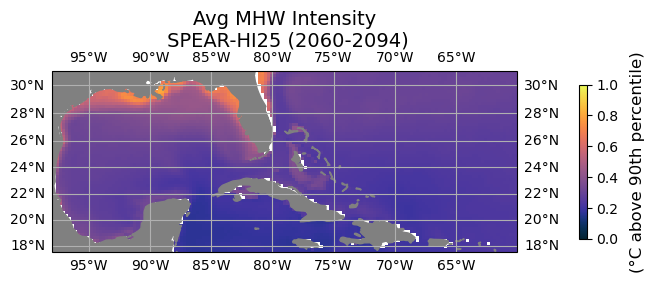

In [32]:
cartopy_plot_single(ens_mean_int, cmocean.cm.thermal, '(°C above 90th percentile)', 
             'Avg MHW Intensity\n SPEAR-HI25 (2060-2094)', vmin=0, vmax=1); 

## (1991-2024) minus (2025-2059)|(2060-2094)

In [10]:
def open_ens_means(pp, var_name):
    path = f'/work5/stb/MHW-gfdl/SPEAR/vars/SPEAR-HI25/period_{pp}/map_vars/ensemble_mean/{var_name}.nc'
    da = xr.open_dataarray(path, chunks={})

    return da

#1994-2024
med_dur_24 = open_ens_means('1991-2024', 'median_duration_ens_mean')
freq_24 = open_ens_means('1991-2024', 'freq_ens_mean')
int_24 = open_ens_means('1991-2024', 'mhw_int_ens_mean')

#2025-2059
med_dur_59 = open_ens_means('2025-2059', 'ens_mean_dur')
freq_59 = open_ens_means('2025-2059', 'ens_mean_freq')
int_59 = open_ens_means('2025-2059', 'ens_mean_int')

#2060-2094
med_dur_94 = open_ens_means('2060-2094', 'ens_mean_dur')
freq_94 = open_ens_means('2060-2094', 'ens_mean_freq')
int_94 = open_ens_means('2060-2094', 'ens_mean_int')

In [8]:
med_dur_24

<xarray.DataArray (yT: 90, xT: 325)> Size: 234kB
dask.array<open_dataset-__xarray_dataarray_variable__, shape=(90, 325), dtype=float64, chunksize=(90, 325), chunktype=numpy.ndarray>
Coordinates:
  * yT       (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
  * xT       (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15

In [11]:
med_dur_59

<xarray.DataArray 'median_duration' (yT: 90, xT: 325)> Size: 234kB
dask.array<open_dataset-median_duration, shape=(90, 325), dtype=float64, chunksize=(90, 325), chunktype=numpy.ndarray>
Coordinates:
  * yT       (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
  * xT       (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15

In [12]:
med_dur_94

<xarray.DataArray 'median_duration' (yT: 90, xT: 325)> Size: 234kB
dask.array<open_dataset-median_duration, shape=(90, 325), dtype=float64, chunksize=(90, 325), chunktype=numpy.ndarray>
Coordinates:
  * yT       (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
  * xT       (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15

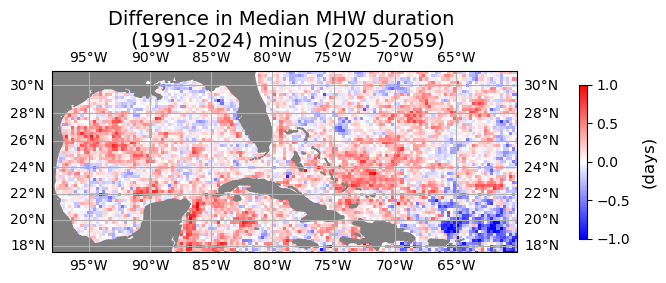

In [27]:
cartopy_plot_single((med_dur_24-med_dur_59), 'bwr', '(days)', 
             'Difference in Median MHW duration \n (1991-2024) minus (2025-2059)', vmin=-1, vmax=1);

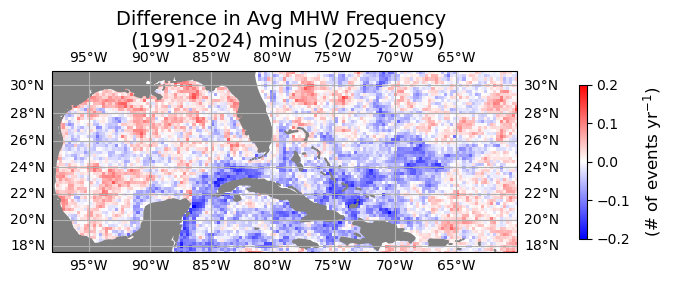

In [28]:
cartopy_plot_single((freq_24-freq_59), 'bwr', r'(# of events yr$^{-1}$)', 
                    'Difference in Avg MHW Frequency \n (1991-2024) minus (2025-2059)', vmin=-0.2, vmax=0.2);

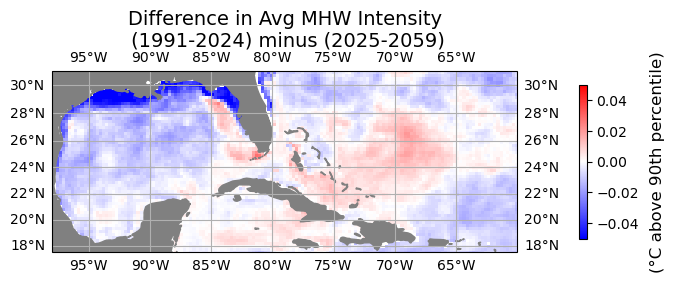

In [29]:
cartopy_plot_single((int_24-int_59), 'bwr', '(°C above 90th percentile)', 
             'Difference in Avg MHW Intensity\n (1991-2024) minus (2025-2059)', vmin=-0.05, vmax=0.05); 

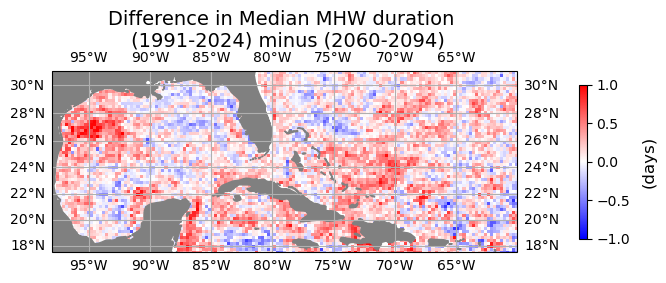

In [30]:
cartopy_plot_single((med_dur_24-med_dur_94), 'bwr', '(days)', 
             'Difference in Median MHW duration \n (1991-2024) minus (2060-2094)', vmin=-1, vmax=1);

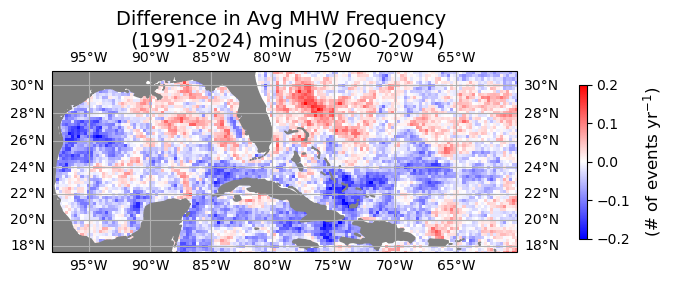

In [31]:
cartopy_plot_single((freq_24-freq_94), 'bwr', r'(# of events yr$^{-1}$)', 
                    'Difference in Avg MHW Frequency \n (1991-2024) minus (2060-2094)', vmin=-0.2, vmax=0.2);

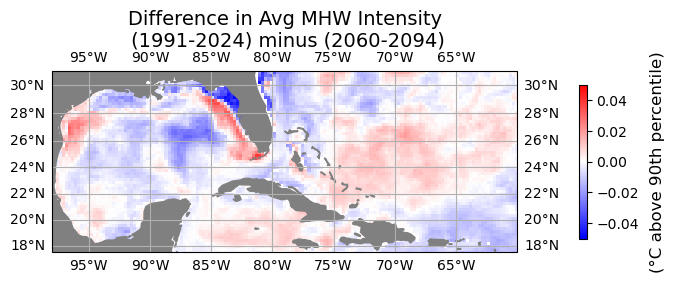

In [32]:
cartopy_plot_single((int_24-int_94), 'bwr', '(°C above 90th percentile)', 
             'Difference in Avg MHW Intensity\n (1991-2024) minus (2060-2094)', vmin=-0.05, vmax=0.05); 